# 3.4 Evaluating Tree-Based Models

## Course 3: Advanced Classification Models for Student Success

## Introduction

In this notebook, we perform a **thorough evaluation** of our three tuned tree-based models. We go beyond simple accuracy or ROC-AUC, and examine precision-recall trade-offs, and confusion matrices, all critical for deploying models trained on imbalanced data in a higher education context.

### Learning Objectives

1. Generate and interpret Precision-Recall curves
2. Analyze confusion matrices for each model
3. Compare feature importances across models
4. Understand probability calibration and threshold selection
5. Make an informed recommendation for deployment

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
project_path = '/content/drive/MyDrive/Applied-Data-Analytics-For-Higher-Education-Course-3'
data_filepath = '/data/'
course3_models = '/models/'

### Data Setup

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
from plotly.subplots import make_subplots

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load and prepare data (same as 3.2)
test_df = pd.read_csv(f'{project_path}{data_filepath}testing.csv')
test_df['DEPARTED'] = (test_df['SEM_3_STATUS'] != 'E').astype(int)

numeric_features = ['HS_GPA','HS_MATH_GPA','HS_ENGL_GPA','UNITS_ATTEMPTED_1','UNITS_ATTEMPTED_2',
    'UNITS_COMPLETED_1','UNITS_COMPLETED_2','DFW_UNITS_1','DFW_UNITS_2','GPA_1','GPA_2',
    'DFW_RATE_1','DFW_RATE_2','GRADE_POINTS_1','GRADE_POINTS_2']
categorical_features = ['RACE_ETHNICITY','GENDER','FIRST_GEN_STATUS','COLLEGE']

test_enc = pd.get_dummies(test_df[numeric_features + categorical_features],
                          columns=categorical_features, drop_first=True)
test_enc = test_enc.fillna(test_enc.median())

X_test, y_test = test_enc, test_df['DEPARTED']


### Load Pre-Trained Models

In [8]:
import joblib

# Dictionary to hold the loaded models
models = {}
# Dictionaries to store predictions and probabilities for evaluation
predictions = {}
probabilities = {}

# Define the filenames for the models to be loaded
model_filenames = {
    'Decision Tree': 'decision_tree_best.joblib',
    'Random Forest': 'random_forest_best.joblib',
    'XGBoost': 'xgboost_early_stopping.joblib'
}

# Load each model, make predictions, and store probabilities
for name, filename in model_filenames.items():
    model_path = f'{project_path}{course3_models}{filename}'
    model = joblib.load(model_path)
    models[name] = model
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Models loaded and predictions/probabilities generated.")
print(f"Models loaded: {list(models.keys())}")
print(f"Predictions keys: {list(predictions.keys())}")
print(f"Probabilities keys: {list(probabilities.keys())}")

Models loaded and predictions/probabilities generated.
Models loaded: ['Decision Tree', 'Random Forest', 'XGBoost']
Predictions keys: ['Decision Tree', 'Random Forest', 'XGBoost']
Probabilities keys: ['Decision Tree', 'Random Forest', 'XGBoost']


## 2. Precision-Recall Curves

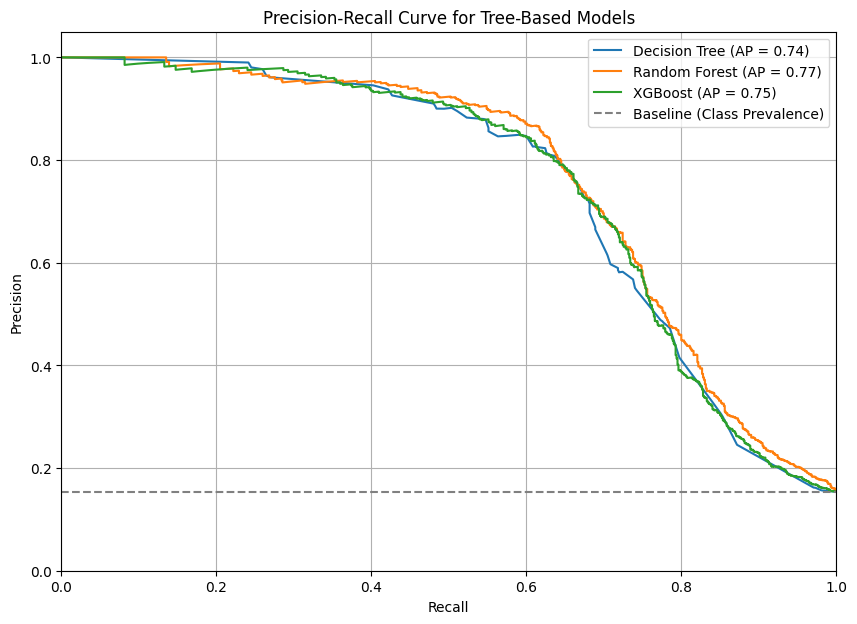

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

# Calculate baseline prevalence
baseline_prevalence = y_test.sum() / len(y_test)

# Plot PR curves for each model
for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap_score = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

# Plot baseline
plt.plot([0, 1], [baseline_prevalence, baseline_prevalence], linestyle='--', color='gray', label='Baseline (Class Prevalence)')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tree-Based Models')
plt.legend()
plt.grid(True)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

## 3. Confusion Matrices

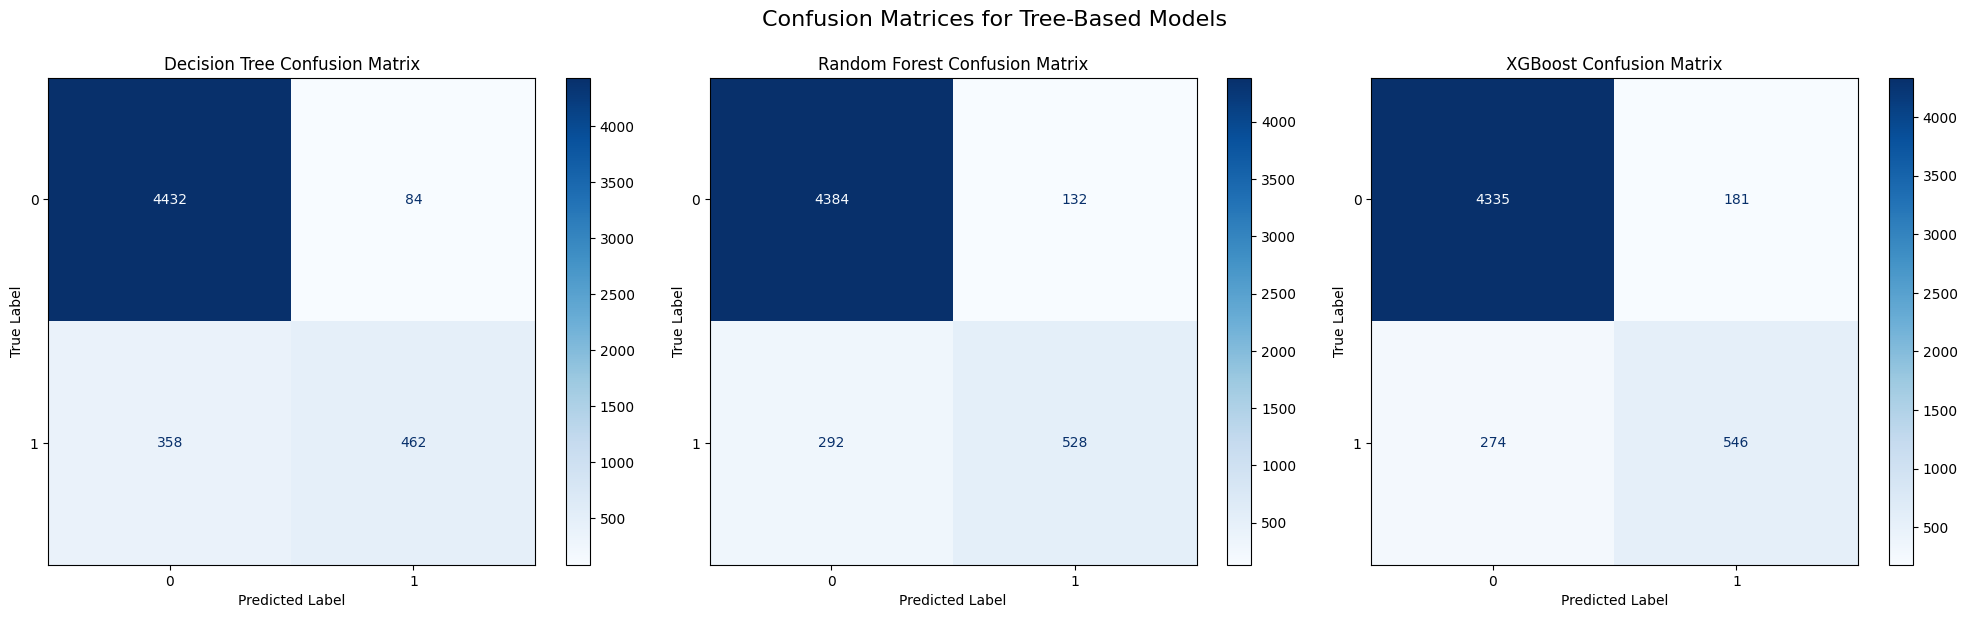

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices for Tree-Based Models', fontsize=16)

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## 4. Summary - Performance Metrics in the Context of Imbalanced Data

When working with imbalanced datasets, standard metrics like accuracy can be misleading. For instance, a model predicting the majority class for all instances might achieve high accuracy but be useless for the minority class, which is often the class of interest.

### Precision-Recall (PR) Curves

PR curves offer a more informative view of model performance on imbalanced data, especially when the positive class is the minority. Unlike ROC curves, which can paint an overly optimistic picture for highly imbalanced datasets, PR curves focus directly on the trade-off between Precision and Recall. This visualization helps us understand how a model performs across different thresholds, providing critical insight into its ability to correctly identify positive instances without generating too many false alarms.

### Confusion Matrices

Confusion matrices provide a detailed breakdown of correct and incorrect classifications. For imbalanced data, examining the raw counts of True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN) is invaluable. This granular view helps identify where the model struggles, especially concerning the minority class. For example, a high number of False Negatives for the minority class (e.g., students who depart but are predicted to enroll) can be immediately identified, highlighting critical areas for model improvement and understanding the practical implications of prediction errors.

### F1 Score

The F1 score is a single metric that balances Precision and Recall. It is particularly useful for imbalanced classification problems because it penalizes models that favor one metric over the other. A high F1 score indicates robust performance where both correctly identified positive predictions and the capture of actual positive instances are strong, which is often desired in imbalanced scenarios.

### Next Module

We will compare these tree-based models against Regularized Logistic Regression in a systematic model comparison framework.

**Proceed to:** `Module 4: Model Comparison and Selection`